In [1]:
import os
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# load splits
train_df = pd.read_csv('../data/processed/train.csv')
val_df = pd.read_csv('../data/processed/val.csv')
test_df = pd.read_csv('../data/processed/test.csv')

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 185659 | Val: 23207 | Test: 23208


In [2]:
# fill any nulls left by preprocessing (rows where all text was stripped)
train_df['clean_text'] = train_df['clean_text'].fillna('')
val_df['clean_text']   = val_df['clean_text'].fillna('')
test_df['clean_text']  = test_df['clean_text'].fillna('')

null_count = (train_df['clean_text'] == '').sum()
print(f"Empty docs in train after fillna: {null_count}")

# fit tfidf on train only — prevents data leakage
vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), min_df=2)

X_train = vectorizer.fit_transform(train_df['clean_text'])
X_val   = vectorizer.transform(val_df['clean_text'])
X_test  = vectorizer.transform(test_df['clean_text'])

y_train = train_df['label']
y_val   = val_df['label']
y_test  = test_df['label']

print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"X_train shape: {X_train.shape}")

Empty docs in train after fillna: 55
Vocabulary size: 50000
X_train shape: (185659, 50000)


In [3]:
# train logistic regression
# C=1.0 is the default regularisation strength
lr = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs')
lr.fit(X_train, y_train)

# quick check on val set
val_preds = lr.predict(X_val)
val_acc = accuracy_score(y_val, val_preds)
print(f"Val accuracy: {val_acc:.4f}")

Val accuracy: 0.9411


In [4]:
# evaluate on test set
test_preds = lr.predict(X_test)

test_acc = accuracy_score(y_test, test_preds)
print(f"Test accuracy: {test_acc:.4f}")
print()
print(classification_report(y_test, test_preds, target_names=['non-suicide', 'suicide']))

Test accuracy: 0.9413

              precision    recall  f1-score   support

 non-suicide       0.93      0.95      0.94     11604
     suicide       0.95      0.93      0.94     11604

    accuracy                           0.94     23208
   macro avg       0.94      0.94      0.94     23208
weighted avg       0.94      0.94      0.94     23208



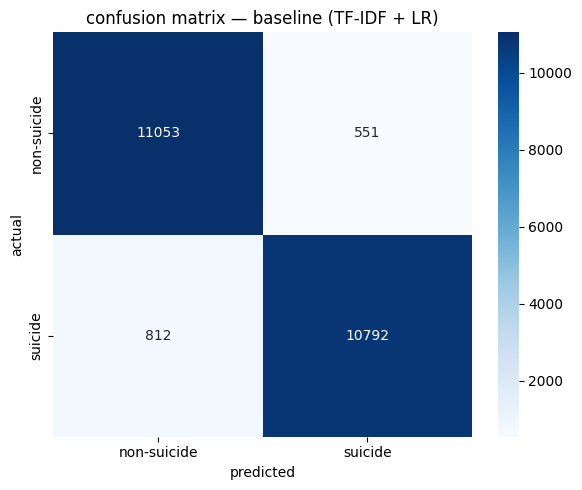

saved to results/confusion_matrix_baseline.png


In [5]:
# confusion matrix
os.makedirs('../results', exist_ok=True)

cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['non-suicide', 'suicide'],
            yticklabels=['non-suicide', 'suicide'])
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('confusion matrix — baseline (TF-IDF + LR)')
plt.tight_layout()
plt.savefig('../results/confusion_matrix_baseline.png', dpi=150)
plt.show()
print("saved to results/confusion_matrix_baseline.png")

In [6]:
# save model and vectoriser so they can be reloaded without retraining
os.makedirs('../models', exist_ok=True)

joblib.dump(lr, '../models/lr_model.pkl')
joblib.dump(vectorizer, '../models/tfidf_vectorizer.pkl')

print("saved lr_model.pkl and tfidf_vectorizer.pkl to models/")

saved lr_model.pkl and tfidf_vectorizer.pkl to models/
